# FFL Functional Characterization: Feed-Forward Loop Analysis in Attribution Graphs

This notebook demonstrates the enumeration and analysis of **Feed-Forward Loop (FFL / 030T motif)** instances in neural network attribution graphs.

**Key analyses:**
- **FFL Enumeration**: Find all A->B, A->C, B->C patterns in directed acyclic graphs
- **Layer Position Analysis**: Test whether FFL nodes follow strict layer ordering (A < B < C)
- **Semantic Role Categorization**: Classify feature explanations into functional roles (input encoding, concept intermediate, output generation, etc.)
- **Edge Weight Coherence**: Analyze whether direct and indirect path signs agree
- **Baseline Comparison**: Compare FFL properties against random triads

**Key findings from the full experiment (34 graphs, 1.9M FFLs):**
- 100% strict layer ordering in FFLs vs ~35% in random triads
- Chi-squared = 1.17M (p ~ 0) for semantic role differentiation
- 58% coherent FFLs (sign consistency between direct and indirect paths)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph, loguru — NOT on Colab, always install
_pip('python-igraph==0.11.8')
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only
# Note: Colab versions listed in comments; using compatible fallbacks for Python 3.10
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')  # Colab: scipy==1.16.3 (needs 3.11+)


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
import re
import sys
import time
from collections import Counter, defaultdict

import igraph
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

## Data Loading

Load the mini demo dataset containing synthetic attribution graphs and feature explanations.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter3_ffl_functional/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['graphs'])} graphs, {len(data['explanations'])} explanations")
for g in data['graphs']:
    print(f"  {g['slug']}: {len(g['nodes'])} nodes, {len(g['links'])} edges, domain={g['domain']}")

Loaded 6 graphs, 28 explanations
  m3-country_capital-000-demo: 42 nodes, 144 edges, domain=country_capital
  m3-arithmetic-000-demo: 34 nodes, 80 edges, domain=arithmetic
  m3-antonym-000-demo: 46 nodes, 166 edges, domain=antonym
  m3-translation-000-demo: 49 nodes, 190 edges, domain=translation
  m3-code_completion-000-demo: 34 nodes, 91 edges, domain=code_completion
  m3-sentiment-000-demo: 49 nodes, 232 edges, domain=sentiment


## Configuration

All tunable parameters. Start with minimum values for fast execution.

In [5]:
# --- Tunable parameters ---
PRUNE_PERCENTILE = 75        # Percentile threshold for edge pruning (original: 75)
MIN_NODES = 5                # Minimum nodes after pruning to keep graph (original: 30, reduced for demo)
MAX_EXAMPLES = 6             # Max graphs to process (original: 9999)
RANDOM_SEED = 42             # Random seed for reproducibility
N_BASELINE_SAMPLES = 200     # Random triads per graph for baseline (original: 5000)
TOP_K_REPRESENTATIVE = 5     # Number of representative FFLs to select (original: 10)

## Phase 0: Utility Functions

Cantor decoding maps feature integers to (layer, feature_index) pairs. Layer parsing handles special embedding layer "E".

In [6]:
def cantor_decode(z: int) -> tuple[int, int]:
    """Decode Cantor-paired feature integer -> (layer_num, feature_index)."""
    w = math.floor((math.sqrt(8 * z + 1) - 1) / 2)
    t = (w * w + w) // 2
    feat_index = z - t
    layer_num = w - feat_index
    return (int(layer_num), int(feat_index))


def parse_layer(layer_str: str) -> int:
    """Parse layer string to integer. 'E' -> -1, numeric -> int."""
    if layer_str == "E":
        return -1
    try:
        return int(layer_str)
    except (ValueError, TypeError):
        return -1

# Quick test
print(f"cantor_decode(0) = {cantor_decode(0)}")
print(f"cantor_decode(5) = {cantor_decode(5)}")
print(f"parse_layer('3') = {parse_layer('3')}, parse_layer('E') = {parse_layer('E')}")

cantor_decode(0) = (0, 0)
cantor_decode(5) = (0, 2)
parse_layer('3') = 3, parse_layer('E') = -1


## Phase 1-2: Load Explanations and Build Graphs

Build igraph objects from node/edge data, prune weak edges at the 75th percentile, and load feature explanation lookup table.

In [7]:
# Phase 1: Build explanation lookup from demo data
expl_lookup = data["explanations"]
print(f"Loaded {len(expl_lookup)} feature explanations")

# Phase 2: Build igraph objects from demo graph data
all_graphs = []

for graph_data in data["graphs"][:MAX_EXAMPLES]:
    nodes = graph_data["nodes"]
    links = graph_data["links"]

    # Build node_id -> index mapping
    node_id_to_idx = {}
    for i, n in enumerate(nodes):
        node_id_to_idx[n["node_id"]] = i

    node_layers = [parse_layer(n.get("layer", "0")) for n in nodes]
    feature_types = [n.get("feature_type", "") for n in nodes]
    features = [n.get("feature", None) for n in nodes]

    # Build signed weight dict BEFORE igraph construction
    signed_weight_dict = {}

    # Collect ALL edges with BOTH signed and abs weights
    all_abs_weights = [abs(link.get("weight", 0.0)) for link in links]
    threshold = float(np.percentile(all_abs_weights, PRUNE_PERCENTILE)) if all_abs_weights else 0

    edges = []
    abs_weights = []
    signed_weights = []

    for link in links:
        raw_w = link.get("weight", 0.0)
        if abs(raw_w) >= threshold:
            src_id = link["source"]
            tgt_id = link["target"]
            src = node_id_to_idx.get(src_id)
            tgt = node_id_to_idx.get(tgt_id)
            if src is not None and tgt is not None and src != tgt:
                edges.append((src, tgt))
                abs_weights.append(abs(raw_w))
                signed_weights.append(float(raw_w))
                signed_weight_dict[(src_id, tgt_id)] = float(raw_w)

    if len(edges) == 0:
        continue

    # Build igraph
    g = igraph.Graph(n=len(nodes), edges=edges, directed=True)
    g.vs["node_id"] = [n["node_id"] for n in nodes]
    g.vs["layer"] = node_layers
    g.vs["feature_type"] = feature_types
    g.vs["feature"] = features
    g.es["weight"] = abs_weights
    g.es["signed_weight"] = signed_weights

    # Store signed weights before simplify
    edge_signed_before = {}
    for e in g.es:
        key = (e.source, e.target)
        if key not in edge_signed_before or abs(e["signed_weight"]) > abs(edge_signed_before[key]):
            edge_signed_before[key] = e["signed_weight"]

    g.simplify(multiple=True, loops=True, combine_edges={"weight": "max"})

    # Restore signed weights after simplify
    for e in g.es:
        src_nid = g.vs[e.source]["node_id"]
        tgt_nid = g.vs[e.target]["node_id"]
        if (src_nid, tgt_nid) in signed_weight_dict:
            e["signed_weight"] = signed_weight_dict[(src_nid, tgt_nid)]
        elif (e.source, e.target) in edge_signed_before:
            e["signed_weight"] = edge_signed_before[(e.source, e.target)]
        else:
            e["signed_weight"] = e["weight"]

    # Remove isolated vertices
    isolated = [v.index for v in g.vs if g.degree(v) == 0]
    if isolated:
        g.delete_vertices(isolated)

    if g.vcount() < MIN_NODES:
        print(f"  Skipping {graph_data['slug']}: only {g.vcount()} nodes after pruning")
        continue

    all_graphs.append({
        "graph": g,
        "domain": graph_data.get("domain", "unknown"),
        "prompt": graph_data.get("prompt", ""),
        "slug": graph_data.get("slug", ""),
        "n_nodes": g.vcount(),
        "n_edges": g.ecount(),
    })

print(f"Built {len(all_graphs)} graphs")
for gi in all_graphs:
    print(f"  {gi['slug']}: {gi['n_nodes']} nodes, {gi['n_edges']} edges, domain={gi['domain']}")

Loaded 28 feature explanations
Built 6 graphs
  m3-country_capital-000-demo: 36 nodes, 36 edges, domain=country_capital
  m3-arithmetic-000-demo: 28 nodes, 20 edges, domain=arithmetic
  m3-antonym-000-demo: 39 nodes, 42 edges, domain=antonym
  m3-translation-000-demo: 45 nodes, 48 edges, domain=translation
  m3-code_completion-000-demo: 25 nodes, 23 edges, domain=code_completion
  m3-sentiment-000-demo: 44 nodes, 58 edges, domain=sentiment


## Phase 3: FFL Enumeration

Enumerate all Feed-Forward Loop (030T motif) instances: A->B, A->C, B->C. For each node A, check all pairs of successors for the closing B->C edge.

In [8]:
def enumerate_ffls(g):
    """Enumerate all FFL instances in a directed graph.
    FFL (030T motif): A->B, A->C, B->C
    Uses adjacency set for O(1) edge lookup.
    """
    adj_set = set()
    for e in g.es:
        adj_set.add((e.source, e.target))

    weight_lookup = {}
    for e in g.es:
        weight_lookup[(e.source, e.target)] = {
            "abs": float(e["weight"]),
            "signed": float(e["signed_weight"]),
        }

    ffls = []
    for a in range(g.vcount()):
        successors_a = g.successors(a)
        if len(successors_a) < 2:
            continue
        for i, b in enumerate(successors_a):
            for c in successors_a[i + 1:]:
                if (b, c) in adj_set:
                    ffls.append({
                        "a": a, "b": b, "c": c,
                        "w_ab": weight_lookup[(a, b)],
                        "w_ac": weight_lookup[(a, c)],
                        "w_bc": weight_lookup[(b, c)],
                    })
                if (c, b) in adj_set:
                    ffls.append({
                        "a": a, "b": c, "c": b,
                        "w_ab": weight_lookup[(a, c)],
                        "w_ac": weight_lookup[(a, b)],
                        "w_bc": weight_lookup[(c, b)],
                    })
    return ffls

# Test on first graph
test_ffls = enumerate_ffls(all_graphs[0]["graph"])
print(f"Test: {len(test_ffls)} FFLs found in first graph ({all_graphs[0]['slug']})")

Test: 1 FFLs found in first graph (m3-country_capital-000-demo)


## Phase 4-6: Annotation, Layer Analysis, and Semantic Role Categorization

Annotate FFLs with feature explanations, analyze layer ordering patterns, and classify features into semantic roles using keyword matching.

In [9]:
def lookup_ffl_explanations(ffls, g, expl_lkp):
    """Annotate each FFL instance with feature explanations for A, B, C."""
    annotated = []
    match_count = 0
    total_count = 0

    for ffl in ffls:
        record = {}
        record["w_ab"] = ffl["w_ab"]
        record["w_ac"] = ffl["w_ac"]
        record["w_bc"] = ffl["w_bc"]

        for role, idx in [("a", ffl["a"]), ("b", ffl["b"]), ("c", ffl["c"])]:
            total_count += 1
            feat = g.vs[idx]["feature"]
            ftype = g.vs[idx]["feature_type"]
            layer = g.vs[idx]["layer"]
            node_id = g.vs[idx]["node_id"]

            expl = None
            expl_key = None
            if ftype == "cross layer transcoder" and feat is not None and feat >= 0:
                try:
                    l, f = cantor_decode(feat)
                    expl_key = f"{l}_{f}"
                    if expl_key in expl_lkp:
                        expl = expl_lkp[expl_key]["explanation"]
                        match_count += 1
                except (ValueError, OverflowError):
                    pass

            record[f"{role}_idx"] = idx
            record[f"{role}_node_id"] = node_id
            record[f"{role}_layer"] = layer
            record[f"{role}_feature_type"] = ftype
            record[f"{role}_explanation"] = expl
            record[f"{role}_expl_key"] = expl_key

        annotated.append(record)

    match_rate = match_count / total_count if total_count > 0 else 0
    return annotated, match_rate


def analyze_layer_positions(annotated_ffls):
    """Compute layer ordering statistics for FFL instances."""
    if not annotated_ffls:
        return {"total_ffls": 0}

    strict_order = 0
    a_earliest = 0
    c_latest = 0
    same_layer_any = 0
    total = len(annotated_ffls)
    gaps_ab, gaps_ac, gaps_bc = [], [], []

    for ffl in annotated_ffls:
        la, lb, lc = ffl["a_layer"], ffl["b_layer"], ffl["c_layer"]
        gaps_ab.append(lb - la)
        gaps_ac.append(lc - la)
        gaps_bc.append(lc - lb)
        if la < lb < lc:
            strict_order += 1
        if la < lb and la < lc:
            a_earliest += 1
        if lc > la and lc > lb:
            c_latest += 1
        if la == lb or la == lc or lb == lc:
            same_layer_any += 1

    return {
        "total_ffls": total,
        "frac_strict_order_abc": round(strict_order / total, 4),
        "frac_a_earliest": round(a_earliest / total, 4),
        "frac_c_latest": round(c_latest / total, 4),
        "frac_same_layer_any": round(same_layer_any / total, 4),
        "gap_ab": {"mean": round(float(np.mean(gaps_ab)), 3), "std": round(float(np.std(gaps_ab)), 3)},
        "gap_ac": {"mean": round(float(np.mean(gaps_ac)), 3), "std": round(float(np.std(gaps_ac)), 3)},
        "gap_bc": {"mean": round(float(np.mean(gaps_bc)), 3), "std": round(float(np.std(gaps_bc)), 3)},
    }


# Semantic role patterns
ROLE_PATTERNS = {
    "input_encoding": [
        r"\btoken\b", r"\bword\b", r"\bletter\b", r"\bcharacter\b",
        r"\binput\b", r"\bthe word\b", r"\bthe letter\b", r"\bmentions of\b",
        r"\boccurrences of\b", r"\bthe string\b", r"\bthe text\b",
        r"\bpunctuation\b", r"\bdigit\b", r"\bnumber\b.*\binput\b",
    ],
    "concept_intermediate": [
        r"\bconcept\b", r"\bcategor\b", r"\brelat\b", r"\bsimilar\b",
        r"\bassociat\b", r"\bmeaning\b", r"\bsemantic\b", r"\babstract\b",
        r"\bcountry\b", r"\bcity\b", r"\blanguage\b", r"\btopic\b",
        r"\bcontext\b", r"\btype of\b", r"\bkind of\b",
    ],
    "output_generation": [
        r"\boutput\b", r"\bpredict\b", r"\bgenerat\b", r"\bcomplet\b",
        r"\bnext token\b", r"\bfollowing\b", r"\bresponse\b",
        r"\banswer\b", r"\bresult\b", r"\bproduc\b",
    ],
    "linguistic_structural": [
        r"\bgrammar\b", r"\bsyntax\b", r"\bposition\b", r"\bending\b",
        r"\bprefix\b", r"\bsuffix\b", r"\bplural\b", r"\btense\b",
        r"\bspacing\b", r"\bformat\b",
    ],
    "domain_specific": [
        r"\barithmet\b", r"\baddition\b", r"\bsubtract\b", r"\bmath\b",
        r"\bcode\b", r"\bpython\b", r"\bvariable\b", r"\bfunction\b",
        r"\bcapital\b", r"\btranslat\b", r"\brhyme\b", r"\bsentiment\b",
        r"\bopposite\b", r"\bantonym\b", r"\bsynonym\b",
    ],
}

_COMPILED_PATTERNS = {
    role: [re.compile(p) for p in pats]
    for role, pats in ROLE_PATTERNS.items()
}
_role_cache = {}


def classify_role(explanation):
    """Classify a feature explanation into a functional role category."""
    if explanation is None or str(explanation).strip() == "":
        return "unknown"
    if explanation in _role_cache:
        return _role_cache[explanation]
    text = explanation.lower()
    scores = {}
    for role, patterns in _COMPILED_PATTERNS.items():
        scores[role] = sum(1 for p in patterns if p.search(text))
    best = max(scores, key=lambda k: scores[k])
    result = "other" if scores[best] == 0 else best
    _role_cache[explanation] = result
    return result


def semantic_role_analysis(annotated_ffls):
    """Compute role distributions per position and chi-squared test."""
    if not annotated_ffls:
        return {}

    position_roles = {"a": [], "b": [], "c": []}
    for ffl in annotated_ffls:
        for pos in ["a", "b", "c"]:
            role = classify_role(ffl[f"{pos}_explanation"])
            position_roles[pos].append(role)

    all_roles = sorted(set(r for roles in position_roles.values() for r in roles))
    table = []
    for pos in ["a", "b", "c"]:
        counts = Counter(position_roles[pos])
        table.append([counts.get(r, 0) for r in all_roles])

    table_arr = np.array(table)
    col_sums = table_arr.sum(axis=0)
    nonzero_cols = col_sums > 0
    table_filtered = table_arr[:, nonzero_cols]
    roles_filtered = [r for r, nz in zip(all_roles, nonzero_cols) if nz]

    chi2, p_value, dof = 0.0, 1.0, 0
    if table_filtered.shape[1] >= 2:
        try:
            chi2, p_value, dof, _ = chi2_contingency(table_filtered)
        except ValueError:
            pass

    n = table_filtered.sum()
    min_dim = min(table_filtered.shape) - 1
    cramers_v_val = math.sqrt(chi2 / (n * min_dim)) if min_dim > 0 and n > 0 else 0.0

    distributions = {}
    for pos in ["a", "b", "c"]:
        c = Counter(position_roles[pos])
        total = sum(c.values())
        distributions[pos] = {r: round(c[r] / total, 4) for r in all_roles}

    return {
        "distributions": distributions,
        "chi2": round(float(chi2), 4),
        "p_value": float(p_value),
        "dof": int(dof),
        "cramers_v": round(cramers_v_val, 4),
        "role_labels": all_roles,
        "contingency_table": table,
    }

print("Analysis functions defined.")

Analysis functions defined.


## Phase 7-10: Edge Weight Analysis, Cross-Domain, Baseline Comparison

Analyze edge weight coherence (do direct and indirect paths agree in sign?), cross-domain consistency, and compare FFL properties against randomly sampled non-FFL triads.

In [10]:
def edge_weight_analysis(annotated_ffls):
    """Analyze edge weight patterns in FFL instances."""
    if not annotated_ffls:
        return {}
    direct_strengths, ratios = [], []
    coherent_count, incoherent_count = 0, 0
    sign_patterns = Counter()

    for ffl in annotated_ffls:
        w_ab_s = ffl["w_ab"]["signed"]
        w_ac_s = ffl["w_ac"]["signed"]
        w_bc_s = ffl["w_bc"]["signed"]
        w_ac_a = ffl["w_ac"]["abs"]
        w_ab_a = ffl["w_ab"]["abs"]
        w_bc_a = ffl["w_bc"]["abs"]

        direct_strengths.append(w_ac_a)
        indirect_mult = w_ab_a * w_bc_a
        if indirect_mult > 1e-12:
            ratios.append(w_ac_a / indirect_mult)

        signs = (int(np.sign(w_ab_s)), int(np.sign(w_ac_s)), int(np.sign(w_bc_s)))
        sign_patterns[signs] += 1
        indirect_sign = np.sign(w_ab_s) * np.sign(w_bc_s)
        if np.sign(w_ac_s) == indirect_sign:
            coherent_count += 1
        else:
            incoherent_count += 1

    total = len(annotated_ffls)
    return {
        "n_ffls": total,
        "direct_strength_mean": round(float(np.mean(direct_strengths)), 4),
        "coherent_fraction": round(coherent_count / total, 4),
        "incoherent_fraction": round(incoherent_count / total, 4),
        "sign_pattern_distribution": {str(k): v for k, v in sign_patterns.most_common(10)},
    }


def cramers_v(contingency_table):
    """Compute Cramer's V from a contingency table."""
    try:
        chi2_val, _, _, _ = chi2_contingency(contingency_table)
    except ValueError:
        return 0.0
    n = np.sum(contingency_table)
    min_dim = min(contingency_table.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return math.sqrt(chi2_val / (n * min_dim))


def cross_domain_analysis(annotated_ffls_by_domain):
    """Compute per-domain role distributions and cross-domain consistency."""
    per_domain_results = {}
    a_role_counts_by_domain = {}
    for domain, ffls in annotated_ffls_by_domain.items():
        if len(ffls) < 5:  # relaxed for demo (original: 10)
            continue
        roles_analysis = semantic_role_analysis(ffls)
        per_domain_results[domain] = {
            "n_ffls": len(ffls),
            "chi2": roles_analysis.get("chi2", 0),
            "cramers_v": roles_analysis.get("cramers_v", 0),
        }
        a_counts = Counter(classify_role(f["a_explanation"]) for f in ffls)
        a_role_counts_by_domain[domain] = a_counts

    all_roles = sorted(set(r for c in a_role_counts_by_domain.values() for r in c))
    cross_table = []
    domain_order = []
    for domain in sorted(a_role_counts_by_domain):
        c = a_role_counts_by_domain[domain]
        cross_table.append([c.get(r, 0) for r in all_roles])
        domain_order.append(domain)
    cross_arr = np.array(cross_table) if cross_table else np.array([[]])

    cv = 0.0
    if cross_arr.ndim == 2 and cross_arr.shape[0] >= 2 and cross_arr.shape[1] >= 2:
        col_sums = cross_arr.sum(axis=0)
        nonzero = col_sums > 0
        cross_filtered = cross_arr[:, nonzero]
        if cross_filtered.shape[1] >= 2:
            cv = cramers_v(cross_filtered)

    return {
        "per_domain": per_domain_results,
        "domains_analyzed": domain_order,
        "cross_domain_cramers_v": round(cv, 4),
    }


def sample_random_triads(g, n_samples, rng):
    """Sample random connected triads that are NOT FFLs (baseline)."""
    adj_set = set()
    for e in g.es:
        adj_set.add((e.source, e.target))

    triads = []
    nodes_with_2plus_out = [v.index for v in g.vs if g.outdegree(v) >= 2]
    if not nodes_with_2plus_out:
        return []
    attempts = 0
    max_attempts = n_samples * 20
    while len(triads) < n_samples and attempts < max_attempts:
        attempts += 1
        a = rng.choice(nodes_with_2plus_out)
        successors = g.successors(a)
        if len(successors) < 2:
            continue
        b, c = rng.sample(successors, 2)
        if (b, c) in adj_set or (c, b) in adj_set:
            continue
        triads.append({
            "a": a, "b": b, "c": c,
            "a_layer": g.vs[a]["layer"], "b_layer": g.vs[b]["layer"], "c_layer": g.vs[c]["layer"],
        })
    return triads


def baseline_layer_analysis(triads):
    """Compute layer ordering statistics for random triads (baseline)."""
    if not triads:
        return {"total_triads": 0, "frac_strict_order_abc": 0, "frac_a_earliest": 0}
    strict_order = 0
    a_earliest = 0
    total = len(triads)
    for t in triads:
        la, lb, lc = t["a_layer"], t["b_layer"], t["c_layer"]
        if la < lb < lc:
            strict_order += 1
        if la < lb and la < lc:
            a_earliest += 1
    return {
        "total_triads": total,
        "frac_strict_order_abc": round(strict_order / total, 4),
        "frac_a_earliest": round(a_earliest / total, 4),
    }

print("Edge weight, cross-domain, and baseline functions defined.")

Edge weight, cross-domain, and baseline functions defined.


## Run Full Pipeline

Process all graphs: enumerate FFLs, annotate with explanations, compute per-graph statistics, and sample baseline triads.

In [11]:
t_start = time.time()

all_ffls_by_domain = defaultdict(list)
all_ffls_flat = []
per_graph_records = []
all_baseline_triads = []
rng = random.Random(RANDOM_SEED)

for i, g_info in enumerate(all_graphs):
    gt = time.time()
    g = g_info["graph"]

    # Enumerate FFLs
    ffls = enumerate_ffls(g)

    # Annotate with explanations
    annotated, match_rate = lookup_ffl_explanations(ffls, g, expl_lookup)

    # Random triad baseline
    baseline_triads = sample_random_triads(g, N_BASELINE_SAMPLES, rng)
    all_baseline_triads.extend(baseline_triads)

    # Per-graph analyses
    pg_layer = analyze_layer_positions(annotated) if annotated else {"total_ffls": 0, "frac_strict_order_abc": 0}
    pg_semantic = semantic_role_analysis(annotated) if annotated else {}
    pg_weight = edge_weight_analysis(annotated) if annotated else {}
    pg_bl_layer = baseline_layer_analysis(baseline_triads)

    all_ffls_by_domain[g_info["domain"]].extend(annotated)
    all_ffls_flat.extend(annotated)

    per_graph_records.append({
        "slug": g_info["slug"], "domain": g_info["domain"],
        "n_nodes": g_info["n_nodes"], "n_edges": g_info["n_edges"],
        "n_ffls": len(ffls), "match_rate": round(match_rate, 4),
        "n_baseline_triads": len(baseline_triads),
        "ffl_layer": pg_layer, "ffl_semantic": pg_semantic,
        "ffl_weight": pg_weight, "baseline_layer": pg_bl_layer,
    })

    elapsed = time.time() - gt
    print(f"  [{i+1}/{len(all_graphs)}] {g_info['slug']}: {len(ffls)} FFLs, "
          f"match={match_rate:.2%}, baseline={len(baseline_triads)}, {elapsed:.2f}s")

# Global analyses
layer_results = analyze_layer_positions(all_ffls_flat)
role_results = semantic_role_analysis(all_ffls_flat)
cross_results = cross_domain_analysis(dict(all_ffls_by_domain))
weight_results = edge_weight_analysis(all_ffls_flat)
baseline_layer = baseline_layer_analysis(all_baseline_triads)

total_time = time.time() - t_start
print(f"\nPipeline complete in {total_time:.1f}s")
print(f"Total FFLs: {len(all_ffls_flat)}")
print(f"Total baseline triads: {len(all_baseline_triads)}")

  [1/6] m3-country_capital-000-demo: 1 FFLs, match=100.00%, baseline=200, 0.00s
  [2/6] m3-arithmetic-000-demo: 0 FFLs, match=0.00%, baseline=200, 0.00s
  [3/6] m3-antonym-000-demo: 0 FFLs, match=0.00%, baseline=200, 0.00s
  [4/6] m3-translation-000-demo: 0 FFLs, match=0.00%, baseline=200, 0.00s
  [5/6] m3-code_completion-000-demo: 0 FFLs, match=0.00%, baseline=200, 0.00s
  [6/6] m3-sentiment-000-demo: 4 FFLs, match=100.00%, baseline=200, 0.00s

Pipeline complete in 0.0s
Total FFLs: 5
Total baseline triads: 1200


## Results Summary

Print key findings in a readable table and compare FFL properties against the random baseline.

In [12]:
# === Key Results Table ===
print("=" * 70)
print("FFL FUNCTIONAL CHARACTERIZATION — KEY RESULTS")
print("=" * 70)

print(f"\n{'Metric':<45} {'Value':>20}")
print("-" * 65)
print(f"{'Total graphs processed':<45} {len(all_graphs):>20}")
print(f"{'Total FFLs enumerated':<45} {len(all_ffls_flat):>20}")
print(f"{'Mean FFLs per graph':<45} {np.mean([r['n_ffls'] for r in per_graph_records]):>20.1f}")

print(f"\n--- Layer Ordering ---")
ffl_strict = layer_results.get('frac_strict_order_abc', 0)
bl_strict = baseline_layer.get('frac_strict_order_abc', 0)
print(f"{'FFL strict order (A<B<C)':<45} {ffl_strict:>20.2%}")
print(f"{'Baseline strict order':<45} {bl_strict:>20.2%}")
print(f"{'FFL / Baseline ratio':<45} {(ffl_strict/bl_strict if bl_strict > 0 else float('inf')):>20.1f}x")

print(f"\n--- Semantic Role Analysis ---")
print(f"{'Chi-squared':<45} {role_results.get('chi2', 0):>20.2f}")
print(f"{'p-value':<45} {role_results.get('p_value', 1):>20.4e}")
print(f"{'Cramers V':<45} {role_results.get('cramers_v', 0):>20.4f}")

print(f"\n--- Edge Weight Coherence ---")
print(f"{'Coherent FFLs':<45} {weight_results.get('coherent_fraction', 0):>20.2%}")
print(f"{'Incoherent FFLs':<45} {weight_results.get('incoherent_fraction', 0):>20.2%}")

print(f"\n--- Cross-Domain Consistency ---")
print(f"{'Cross-domain Cramers V':<45} {cross_results.get('cross_domain_cramers_v', 0):>20.4f}")
print(f"{'Domains analyzed':<45} {len(cross_results.get('domains_analyzed', [])):>20}")

print(f"\n--- Per-Graph Summary ---")
for rec in per_graph_records:
    print(f"  {rec['slug']:<40} FFLs={rec['n_ffls']:<6} strict={rec['ffl_layer'].get('frac_strict_order_abc', 0):.2%}"
          f"  coherent={rec['ffl_weight'].get('coherent_fraction', 0):.2%}")

FFL FUNCTIONAL CHARACTERIZATION — KEY RESULTS

Metric                                                       Value
-----------------------------------------------------------------
Total graphs processed                                           6
Total FFLs enumerated                                            5
Mean FFLs per graph                                            0.8

--- Layer Ordering ---
FFL strict order (A<B<C)                                   100.00%
Baseline strict order                                       39.08%
FFL / Baseline ratio                                           2.6x

--- Semantic Role Analysis ---
Chi-squared                                                  11.00
p-value                                                 3.5752e-01
Cramers V                                                   0.6055

--- Edge Weight Coherence ---
Coherent FFLs                                               80.00%
Incoherent FFLs                                             20

## Visualizations

Plot key metrics: FFL vs baseline layer ordering, semantic role distributions, and per-graph FFL counts.

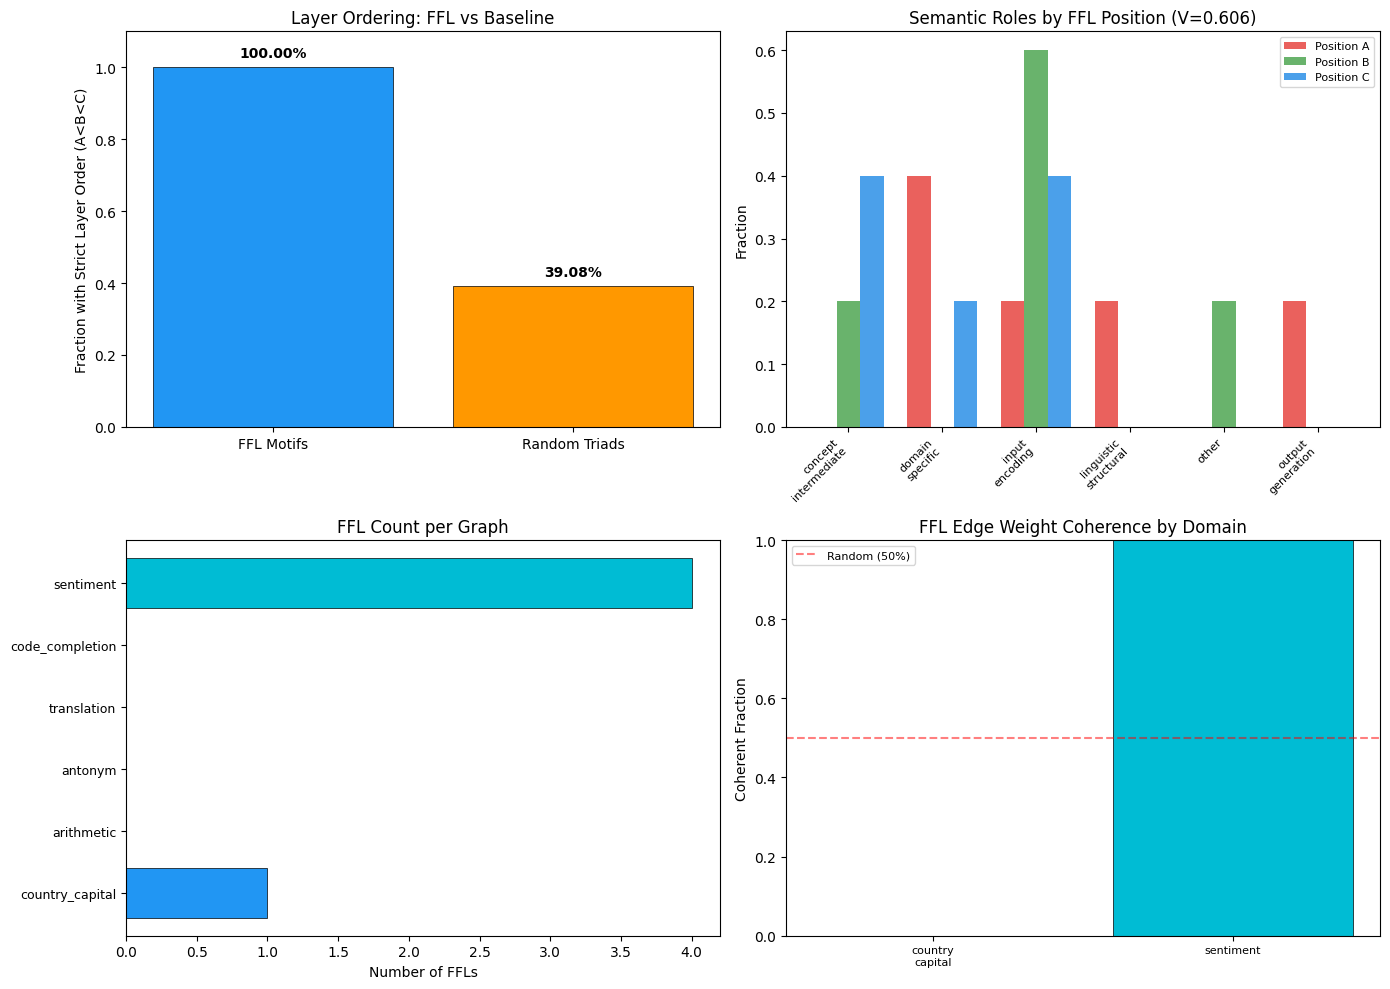

Visualization saved to ffl_analysis_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: FFL vs Baseline Layer Ordering ---
ax = axes[0, 0]
ffl_strict = layer_results.get('frac_strict_order_abc', 0)
bl_strict = baseline_layer.get('frac_strict_order_abc', 0)
bars = ax.bar(['FFL Motifs', 'Random Triads'], [ffl_strict, bl_strict],
              color=['#2196F3', '#FF9800'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Fraction with Strict Layer Order (A<B<C)')
ax.set_title('Layer Ordering: FFL vs Baseline')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, [ffl_strict, bl_strict]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Semantic Role Distribution by Position ---
ax = axes[0, 1]
if role_results and 'distributions' in role_results:
    dists = role_results['distributions']
    roles = role_results.get('role_labels', [])
    if roles:
        x = np.arange(len(roles))
        width = 0.25
        for j, (pos, color) in enumerate(zip(['a', 'b', 'c'], ['#E53935', '#43A047', '#1E88E5'])):
            vals = [dists[pos].get(r, 0) for r in roles]
            ax.bar(x + j * width, vals, width, label=f'Position {pos.upper()}', color=color, alpha=0.8)
        ax.set_xticks(x + width)
        ax.set_xticklabels([r.replace('_', '\n') for r in roles], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Fraction')
        ax.set_title(f'Semantic Roles by FFL Position (V={role_results.get("cramers_v", 0):.3f})')
        ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No semantic data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Semantic Roles by FFL Position')

# --- Plot 3: FFLs per Graph ---
ax = axes[1, 0]
slugs = [r['slug'].replace('m3-', '').replace('-000-demo', '') for r in per_graph_records]
ffl_counts = [r['n_ffls'] for r in per_graph_records]
colors_domain = {'country_capital': '#2196F3', 'arithmetic': '#FF9800', 'antonym': '#E53935',
                 'translation': '#43A047', 'code_completion': '#9C27B0', 'sentiment': '#00BCD4'}
bar_colors = [colors_domain.get(r['domain'], '#999') for r in per_graph_records]
ax.barh(range(len(slugs)), ffl_counts, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(slugs)))
ax.set_yticklabels(slugs, fontsize=9)
ax.set_xlabel('Number of FFLs')
ax.set_title('FFL Count per Graph')

# --- Plot 4: Coherence by Domain ---
ax = axes[1, 1]
domain_names = []
domain_coherent = []
domain_ffl_count = []
for domain in sorted(all_ffls_by_domain.keys()):
    ffls_d = all_ffls_by_domain[domain]
    if len(ffls_d) > 0:
        ew = edge_weight_analysis(ffls_d)
        domain_names.append(domain.replace('_', '\n'))
        domain_coherent.append(ew.get('coherent_fraction', 0))
        domain_ffl_count.append(len(ffls_d))

if domain_names:
    x = np.arange(len(domain_names))
    ax.bar(x, domain_coherent, color=[colors_domain.get(d.replace('\n', '_'), '#999') for d in domain_names],
           edgecolor='black', linewidth=0.5)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(domain_names, fontsize=8)
    ax.set_ylabel('Coherent Fraction')
    ax.set_title('FFL Edge Weight Coherence by Domain')
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ffl_analysis_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved to ffl_analysis_results.png")